# 연습 04

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
data3 = data.loc[:,['city_code', 'gender','waist']]


In [21]:
data3.head()

,city_code,gender,waist
0,36,1,72.1
1,27,2,81.0
2,11,2,70.0
3,31,1,90.8
4,41,2,75.2


In [22]:
male_data = data3[data3['gender'] == 1].groupby('city_code')['waist'].mean()
female_data = data3[data3['gender'] == 2].groupby('city_code')['waist'].mean()
male_data.head()

city_code
11    85.278873
26    85.991429
27    86.340000
28    86.603333
29    86.135714
Name: waist, dtype: float64

In [23]:
female_data.head()

city_code
11    77.520930
26    76.718182
27    75.538710
28    79.612903
29    75.766667
Name: waist, dtype: float64

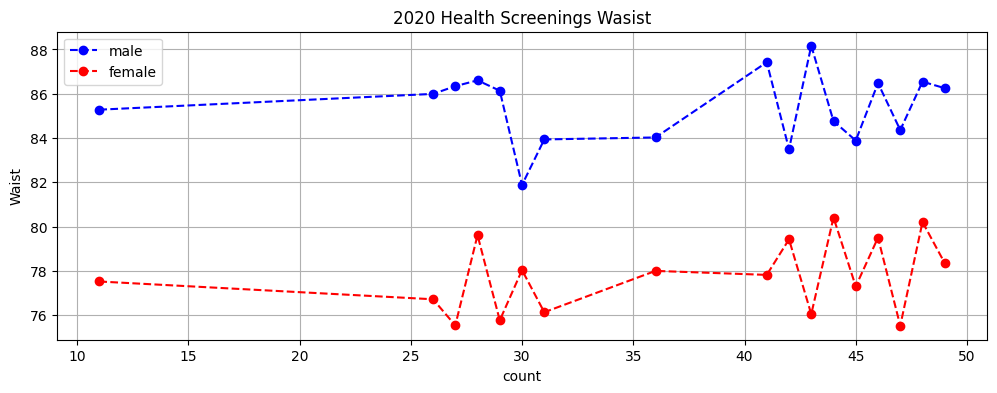

In [24]:
plt.figure(figsize=(12,4))

plt.plot(male_data, color='b', marker='o', linestyle='--', label='male') 
#plt.plot(male_data, 'bo--', label='male') -->줄여서 한꺼번에 표기 가능
plt.plot(female_data, color='r', marker='o', linestyle='--', label='female' ) 
#plt.plot(female_data, 'bo--', label='female')
plt.xlabel('count')
plt.ylabel('Waist')
plt.title('2020 Health Screenings Wasist')
plt.legend()
plt.grid()
plt.show()

# 연습 5

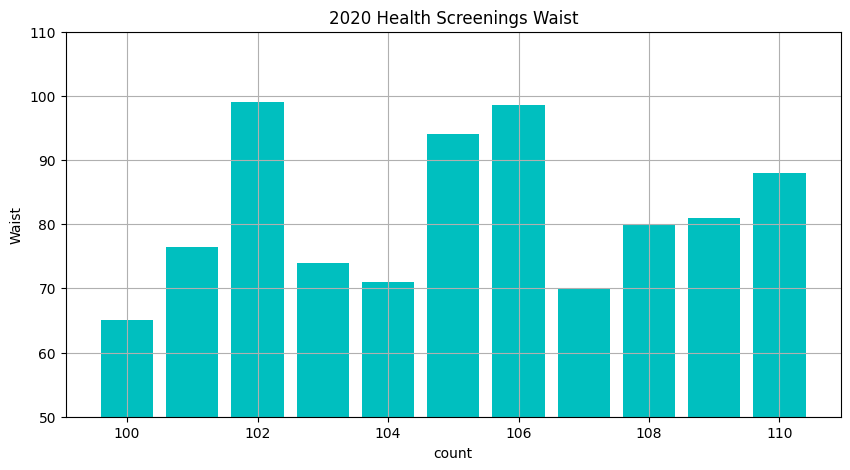

In [32]:
waistData=data3.loc[100:110, ['waist']]

plt.figure(figsize=(10,5))

plt.bar(waistData.index, waistData['waist'], color='c')

plt.ylim(50,110)
plt.xlabel('count')
plt.ylabel('Waist')
plt.title('2020 Health Screenings Waist')
plt.grid()
plt.show()


In [26]:
waistData.head()


,waist
100,65.0
101,76.5
102,99.1
103,74.0
104,71.0


# 연습 6

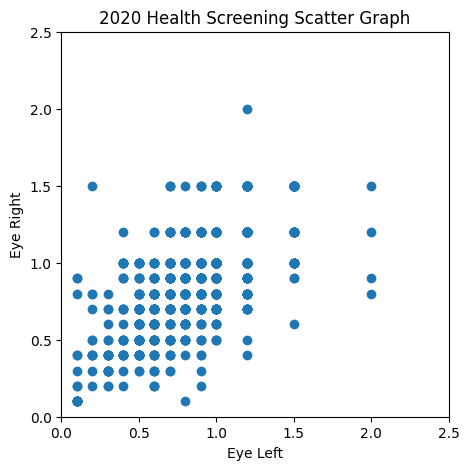

In [27]:
lEyeData = data['eye_left']
rEyeData = data['eye_right']

plt. figure(figsize=(5,5))

plt.scatter(x=lEyeData, y=rEyeData)  

plt.title('2020 Health Screening Scatter Graph')
plt.xlim(0, 2.5)
plt.ylim(0, 2.5)
plt.xlabel('Eye Left')
plt.ylabel('Eye Right')

plt.show()


# 연습 7

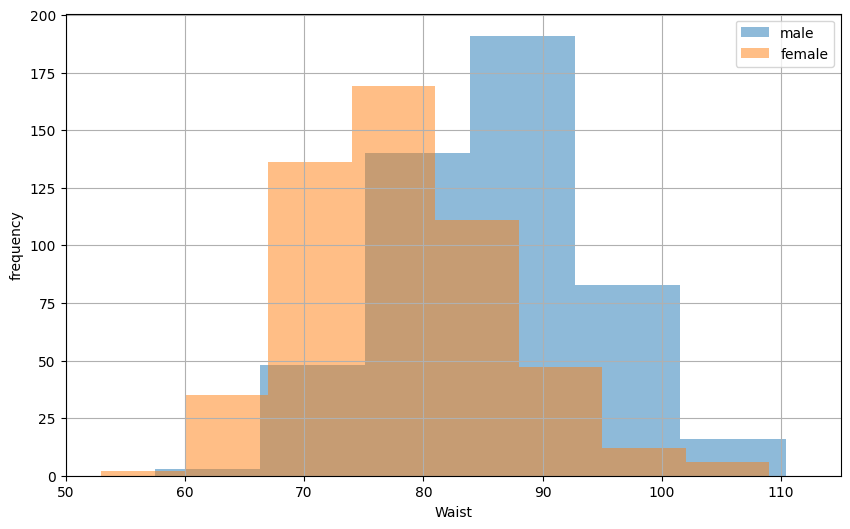

In [28]:
data3 = data.loc[:, ['city_code', 'gender', 'waist']]

male_data = data3.loc[data3.gender == 1, ['gender', 'waist']]
female_data = data3.loc[data3.gender == 2, ['gender', 'waist']]

plt.figure(figsize=(10, 6))

plt.hist(male_data['waist'], bins=8, alpha=0.5, label='male') 
plt.hist(female_data['waist'], bins=8, alpha=0.5, label='female')


plt.xlim(50, 115)
plt.xlabel('Waist')
plt.ylabel('frequency')
plt.legend()
plt.grid() 
plt.show()

# 연습 8

C:\Users\Administrator\AppData\Local\Temp\ipykernel_12084\1489874133.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


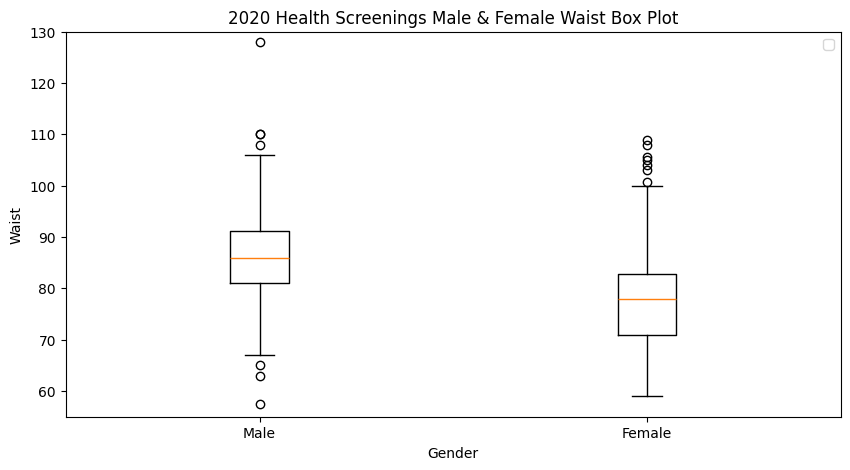

In [29]:
mandata = data3.loc[data3.gender == 1, ['gender', 'waist']]
womandata = data3.loc[data3.gender == 2, ['gender', 'waist']]

male = np.array(mandata['waist'], dtype=object)
female = np.array(womandata['waist'], dtype=object)

plt.figure(figsize=(10, 5))
plt.boxplot([male, female], tick_labels=['Male','Female'])

plt.ylim(55, 130)
plt.xlabel('Gender')
plt.ylabel('Waist')
plt.title('2020 Health Screenings Male & Female Waist Box Plot')
plt.legend()
plt.show()

# 연습 9

In [30]:

data6 = data.loc[:,['gender', 'height', 'weight', 'waist', 'drinking', 'smoking']]
data6.head()


,gender,height,weight,waist,drinking,smoking
0,1,165,60,72.1,0,1
1,2,150,65,81.0,0,1
2,2,155,55,70.0,0,1
3,1,160,70,90.8,0,1
4,2,155,50,75.2,0,1


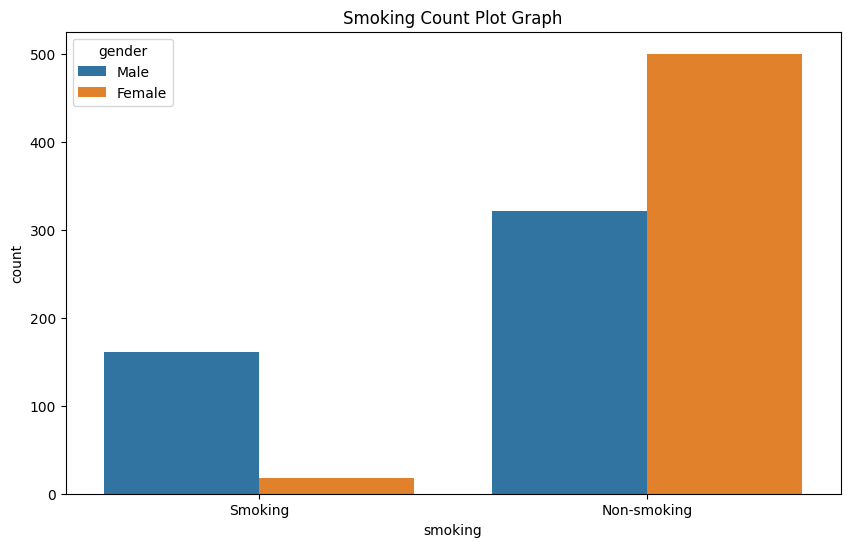

In [31]:
data6 = data.loc[:,['gender', 'height', 'weight', 'waist', 'drinking', 'smoking']]

data6['gender'] = data6['gender'].map({1:'Male', 2:'Female'})  #교재 9,10 줄 축소

data6['smoking'] = data6['smoking'].map({1:'Non-smoking', 2:'Non-smoking', 3:'Smoking'}) ##교재 11,12 줄 축소

data6['drinking'] = data6['drinking'].map({0:'Non-drinking', 1:'Drinking'}) ##교재 14,15 줄 축소


smoking = data6.groupby(['gender','smoking'])['smoking'].count()
smoking = smoking.to_frame(name='count')
smoking = smoking.reset_index()


plt.figure(figsize=(10,6))

sns.countplot(data=data6, x='smoking', hue='gender', order=['Smoking','Non-smoking'])

plt.title('Smoking Count Plot Graph')
plt.show()

